In [1]:
!pip install qwen-vl-utils bitsandbytes evaluate rouge_score bert_score

In [2]:
import os
import gc
import json
import base64
import io

# Debug: force sync CUDA errors for clearer stack traces.
# Restart the kernel after changing this value.
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# os.environ['TORCH_USE_CUDA_DSA'] = "1"

import torch
from PIL import Image
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from peft import PeftModel
from qwen_vl_utils import process_vision_info
import evaluate

# =========================================================
# ENVIRONMENT AUTODETECT (KAGGLE VS LOCAL)
# =========================================================
IS_KAGGLE = os.path.exists("/kaggle/working/")

if IS_KAGGLE:
    print("Environment: KAGGLE")
    OUTPUT_DIR = "/kaggle/input/models/kaylarizaa/finetune-new/pytorch/default/1/finetune_qwen_vlm_qlora/qwen_vlm_finetuned"
    LORA_ADAPTER_DIR = "/kaggle/input/models/kaylarizaa/finetune-new/pytorch/default/1/finetune_qwen_vlm_qlora/qwen_vlm_finetuned/lora_adapter"
    DORA_OUTPUT_DIR = "/kaggle/input/models/kaylarizaa/finetune-new/pytorch/default/1/qwen_qdora/qwen_qdora"
    DORA_ADAPTER_DIR = "/kaggle/input/models/kaylarizaa/finetune-new/pytorch/default/1/qwen_qdora/qwen_qdora/lora_adapter"
    DATASET_PATH = "/kaggle/input/datasets/henryalifian/vlm-dataset/vlm_dataset_v2.jsonl"
    PANELS_DIR = "/kaggle/input/datasets/henryalifian/vlm-dataset/results/vlm_dataset/panels"
else:
    print("Environment: LOCAL PC")
    OUTPUT_DIR = "qwen_vlm_finetuned"
    LORA_ADAPTER_DIR = os.path.join(OUTPUT_DIR, "lora_adapter")
    DORA_OUTPUT_DIR = "qwen_ft_dora"
    DORA_ADAPTER_DIR = os.path.join(DORA_OUTPUT_DIR, "lora_adapter")
    DATASET_PATH = "vlm_dataset/vlm_dataset.jsonl"
    PANELS_DIR = "vlm_dataset/panels"

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB)")

Environment: KAGGLE
CUDA Available: True
GPU: Tesla T4 (14.6 GB)


In [3]:
# Load test images split
try:
    with open(os.path.join(OUTPUT_DIR, "split_info.json"), "r") as f:
        split_info = json.load(f)
    test_images = set(split_info.get("test_images", []))
except FileNotFoundError:
    print("Warning: split_info.json not found! Fallback to reading raw dataset.")
    test_images = set()

test_data = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        entry = json.loads(line.strip())
        if (entry.get("image", "") in test_images) or len(test_images) == 0:
            if not entry.get("output", "").startswith("[API_ERROR]"):
                test_data.append(entry)

print(f"Loaded {len(test_data)} valid testing samples.")

Loaded 774 valid testing samples.


In [4]:
# LOAD MODEL DAN PROCESSOR
MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

# 4-bit config is CRITICAL for 8GB VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
 )

def _resolve_adapter_dir(root_dir):
    if not root_dir or not os.path.exists(root_dir):
        return None

    # Kandidat cepat yang umum dipakai.
    direct_candidates = [
        root_dir,
        os.path.join(root_dir, "lora_adapter"),
    ]
    for c in direct_candidates:
        if os.path.exists(os.path.join(c, "adapter_config.json")):
            return c

    # Fallback: cari rekursif adapter_config.json di bawah root_dir.
    found = []
    for walk_root, _, files in os.walk(root_dir):
        if "adapter_config.json" in files:
            found.append(walk_root)

    if not found:
        return None

    # Prioritaskan folder bernama lora_adapter, lalu path terpendek.
    found.sort(key=lambda p: ("lora_adapter" not in p.replace("\\", "/"), len(p)))
    return found[0]

adapter_path = _resolve_adapter_dir(LORA_ADAPTER_DIR if 'LORA_ADAPTER_DIR' in globals() else OUTPUT_DIR)
dora_adapter_path = _resolve_adapter_dir(DORA_ADAPTER_DIR if 'DORA_ADAPTER_DIR' in globals() else DORA_OUTPUT_DIR)

print(f"Resolved LoRA adapter path: {adapter_path}")
print(f"Resolved DoRA adapter path: {dora_adapter_path}")

print("Loading processors...")
processor_base = AutoProcessor.from_pretrained(MODEL_NAME)

if adapter_path:
    try:
        processor_ft = AutoProcessor.from_pretrained(adapter_path)
        print("Loaded finetuned processor from LoRA adapter.")
    except Exception:
        processor_ft = processor_base
        print("Loaded base processor for LoRA model (fallback).")
else:
    processor_ft = processor_base
    print("LoRA adapter not found. Using base processor.")

if dora_adapter_path:
    try:
        processor_dora = AutoProcessor.from_pretrained(dora_adapter_path)
        print("Loaded finetuned processor from DoRA adapter.")
    except Exception:
        processor_dora = processor_base
        print("Loaded base processor for DoRA model (fallback).")
else:
    processor_dora = processor_base
    print("DoRA adapter not found. Using base processor.")

for proc in (processor_base, processor_ft, processor_dora):
    if proc.tokenizer.pad_token_id is None:
        proc.tokenizer.pad_token_id = proc.tokenizer.eos_token_id

print("Loading base model (4-bit)...")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    attn_implementation="eager",
 )
base_model.eval()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

HAS_LORA = False
HAS_DORA = False
peft_model_for_infer = None

# Muat LoRA sebagai adapter bernama "lora"
if adapter_path:
    print("Loading LoRA adapter as 'lora'...")
    try:
        peft_model_for_infer = PeftModel.from_pretrained(
            base_model,
            adapter_path,
            adapter_name="lora",
            is_trainable=False,
        )
        peft_model_for_infer.eval()
        HAS_LORA = True
    except Exception as e:
        print("LoRA load failed. Error:", str(e))

# Muat DoRA sebagai adapter bernama "dora" (di model PEFT yang sama jika sudah ada LoRA)
if dora_adapter_path:
    print("Loading DoRA adapter as 'dora'...")
    try:
        if peft_model_for_infer is None:
            peft_model_for_infer = PeftModel.from_pretrained(
                base_model,
                dora_adapter_path,
                adapter_name="dora",
                is_trainable=False,
            )
        else:
            peft_model_for_infer.load_adapter(
                dora_adapter_path,
                adapter_name="dora",
                is_trainable=False,
            )
        peft_model_for_infer.eval()
        HAS_DORA = True
    except Exception as e:
        print("DoRA load failed. Error:", str(e))

if peft_model_for_infer is None:
    print("No PEFT adapter loaded. Using base model only.")
    model_for_infer = base_model
else:
    model_for_infer = peft_model_for_infer
    print("Available adapters:", list(model_for_infer.peft_config.keys()))

# Supaya kompatibel dengan cell evaluasi yang sudah ada
base_model_for_infer = model_for_infer
finetuned_model = model_for_infer
dora_model_for_infer = model_for_infer

print("Model & Processor loaded and ready!")

Resolved LoRA adapter path: /kaggle/input/models/kaylarizaa/finetune-new/pytorch/default/1/finetune_qwen_vlm_qlora/qwen_vlm_finetuned/lora_adapter
Resolved DoRA adapter path: /kaggle/input/models/kaylarizaa/finetune-new/pytorch/default/1/qwen_qdora/qwen_qdora/lora_adapter
Loading processors...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded finetuned processor from LoRA adapter.
Loaded finetuned processor from DoRA adapter.
Loading base model (4-bit)...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading LoRA adapter as 'lora'...
Loading DoRA adapter as 'dora'...
Available adapters: ['lora', 'dora']
Model & Processor loaded and ready!


In [5]:
def _calc_target_size(image, max_w=840, max_h=280):
    w, h = image.size
    scale = min(max_w / w, max_h / h, 1.0)
    w = int(w * scale)
    h = int(h * scale)

    # Round to nearest multiple of 28, and keep at least 28.
    w = max(28, int(round(w / 28)) * 28)
    h = max(28, int(round(h / 28)) * 28)
    return w, h


def generate_diagnosis(
    model,
    processor,
    img_path,
    instruction,
    input_data_json,
    adapter_name=None,
    max_new_tokens=256,
):
    try:
        image = Image.open(img_path).convert("RGB")
        target_w, target_h = _calc_target_size(image)

        if not isinstance(input_data_json, str):
            input_data_json = json.dumps(input_data_json, ensure_ascii=True)

        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                        "resized_width": target_w,
                        "resized_height": target_h,
                    },
                    {"type": "text", "text": f"{instruction}\n{input_data_json}"},
                ],
            }
        ]

        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(messages)

        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )

        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        # Pilih adapter spesifik saat inferensi jika model adalah PEFT multi-adapter.
        if adapter_name not in (None, "__base__") and hasattr(model, "set_adapter"):
            try:
                model.set_adapter(adapter_name)
            except Exception as e:
                print(f"Warning: gagal set adapter '{adapter_name}': {e}")

        torch.cuda.empty_cache()
        gc.collect()

        with torch.inference_mode():
            if adapter_name == "__base__" and hasattr(model, "disable_adapter"):
                with model.disable_adapter():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=max_new_tokens,
                        temperature=0.3,
                        do_sample=True,
                    )
            else:
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    temperature=0.3,
                    do_sample=True,
                )

        generated_ids = outputs[0][inputs["input_ids"].shape[1] :]
        result = processor.decode(generated_ids, skip_special_tokens=True)

        del inputs, outputs
        torch.cuda.empty_cache()

        return result
    except Exception as e:
        return f"[ERROR GENERATING] {str(e)}"

Generating BASE responses for Sample #1...
Generating LoRA responses for Sample #1...
Generating DoRA responses for Sample #1...



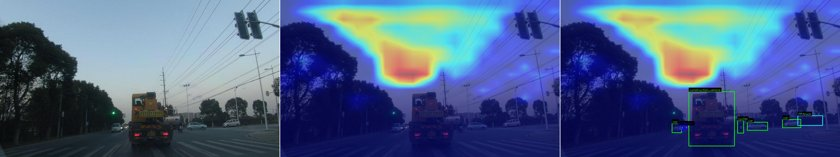

In [6]:
from IPython.display import display, HTML

NUM_SAMPLES = 1
samples = test_data[: min(NUM_SAMPLES, len(test_data))]

# Deklarasi metrik & list prediksi di luar loop
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

predictions_base = []
predictions_ft = []
predictions_dora = []
references = []

def _img_to_base64(path, max_width=840):
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if w > max_width:
        new_h = int(h * (max_width / w))
        img = img.resize((max_width, new_h))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode("utf-8")


styles = """
<style>
  .report { font-family: "Segoe UI", Tahoma, Geneva, Verdana, sans-serif; color: #222; }
  .card { border: 1px solid #ddd; border-radius: 10px; background: #fff; margin: 14px 0; box-shadow: 0 2px 10px rgba(0,0,0,0.06); }
  .card-head { padding: 10px 14px; background: #f7f7f7; border-bottom: 1px solid #eee; font-size: 14px; }
  .card-body { padding: 14px; }
  .img-wrap { text-align: center; margin-bottom: 12px; }
  .img-wrap img { max-width: 100%; border-radius: 8px; }
  .meta { font-size: 12px; color: #555; margin-bottom: 10px; }
  .grid { display: grid; grid-template-columns: repeat(4, 1fr); gap: 10px; }
  .box { border: 1px solid #e3e3e3; border-top: 4px solid #888; border-radius: 8px; padding: 12px; background: #fcfcfc; }
  .box h4 { margin: 0 0 6px 0; font-size: 13px; }
  .box p { margin: 0; font-size: 12.5px; line-height: 1.5; }
  .tag { display: inline-block; padding: 2px 6px; border-radius: 4px; background: #eee; font-size: 11px; }
  @media (max-width: 900px) { .grid { grid-template-columns: 1fr; } }
</style>
"""

html_output = styles + "<div class='report'><h2>Hasil Analisis Qwen2-VL (Base vs LoRA vs DoRA)</h2>"

adapter_name_base = "__base__"
adapter_name_lora = "lora" if HAS_LORA else "__base__"
adapter_name_dora = "dora" if HAS_DORA else "__base__"

for i, sample in enumerate(samples):
    img_name = sample.get("image", "")
    img_path = os.path.join(PANELS_DIR, img_name)

    if not os.path.exists(img_path):
        html_output += f"<div class='card'><div class='card-body'><b>Warning:</b> Image path not found: {img_path}</div></div>"
        continue

    input_str = sample.get("input", "")
    try:
        parsed_input = json.loads(input_str)
    except Exception:
        parsed_input = {}

    print(f"Generating BASE responses for Sample #{i+1}...")
    before_text = generate_diagnosis(
        base_model_for_infer,
        processor_base,
        img_path=img_path,
        instruction=sample.get("instruction", ""),
        input_data_json=input_str,
        adapter_name=adapter_name_base,
    )

    print(f"Generating LoRA responses for Sample #{i+1}...")
    after_text = generate_diagnosis(
        finetuned_model,
        processor_ft,
        img_path=img_path,
        instruction=sample.get("instruction", ""),
        input_data_json=input_str,
        adapter_name=adapter_name_lora,
    )

    print(f"Generating DoRA responses for Sample #{i+1}...")
    dora_text = generate_diagnosis(
        dora_model_for_infer,
        processor_dora,
        img_path=img_path,
        instruction=sample.get("instruction", ""),
        input_data_json=input_str,
        adapter_name=adapter_name_dora,
    )

    ground_truth = sample.get("output", "")

    predictions_base.append(before_text)
    predictions_ft.append(after_text)
    predictions_dora.append(dora_text)
    references.append(ground_truth)

    obj_info = f"{parsed_input.get('object_class', 'N/A').upper()} ({parsed_input.get('object_type', 'N/A')})"
    risk_info = parsed_input.get("risk_tier", "N/A")

    img_b64 = _img_to_base64(img_path)
    img_html = f"<div class='img-wrap'><img src='data:image/jpeg;base64,{img_b64}' /></div>"

    def format_text(title, text, color):
        formatted = text.replace("\n", "<br>")
        return (
            "<div class='box' style='border-top-color: "
            + color
            + ";'>"
            + f"<h4 style='color:{color};'>{title}</h4>"
            + f"<p>{formatted}</p>"
            + "</div>"
        )

    html_output += f"""
    <div class='card'>
      <div class='card-head'>
        <b>Sample #{i+1}</b> <span class='tag'>{img_name}</span>
      </div>
      <div class='card-body'>
        {img_html}
        <div class='meta'><b>Deteksi:</b> {obj_info} &nbsp; | &nbsp; <b>Risk:</b> {risk_info}</div>
        <div class='grid'>
          {format_text("BASE MODEL (Qwen2-VL-2B)", before_text, "#e74c3c")}
          {format_text("FINETUNED LoRA", after_text, "#2ecc71")}
          {format_text("FINETUNED DoRA", dora_text, "#f39c12")}
          {format_text("GROUND TRUTH (Gemini Data)", ground_truth, "#3498db")}
        </div>
      </div>
    </div>
    """

html_output += "</div>"

display(HTML(html_output))

In [10]:
# ==========================================
# PERHITUNGAN METRIK KOMPARATIF (BASE VS LORA VS DORA)
# ==========================================
print("\n" + "="*60)
print("MENGHITUNG METRIK EVALUASI KORPUS (BERTScore)...")
print("="*60)

# Hitung Base Model
bert_base = bertscore_metric.compute(
    predictions=predictions_base,
    references=references,
    lang="en",
    model_type="distilroberta-base"
 )
avg_bert_base = sum(bert_base['f1']) / len(bert_base['f1'])

# Hitung LoRA Model
bert_ft = bertscore_metric.compute(
    predictions=predictions_ft,
    references=references,
    lang="en",
    model_type="distilroberta-base"
 )
avg_bert_ft = sum(bert_ft['f1']) / len(bert_ft['f1'])

# Hitung DoRA Model
bert_dora = bertscore_metric.compute(
    predictions=predictions_dora,
    references=references,
    lang="en",
    model_type="distilroberta-base"
 )
avg_bert_dora = sum(bert_dora['f1']) / len(bert_dora['f1'])

# Hitung Delta terhadap baseline
delta_lora = avg_bert_ft - avg_bert_base
delta_dora = avg_bert_dora - avg_bert_base

print(f"BASELINE (Qwen2-VL Base) BERTScore : {avg_bert_base:.4f}")
print(f"FINETUNED (LoRA Adapter) BERTScore : {avg_bert_ft:.4f}")
print(f"FINETUNED (DoRA Adapter) BERTScore : {avg_bert_dora:.4f}")
print(f"Delta LoRA vs Base: {delta_lora:+.4f}")
print(f"Delta DoRA vs Base: {delta_dora:+.4f}")

best_label = max(
    [("BASE", avg_bert_base), ("LoRA", avg_bert_ft), ("DoRA", avg_bert_dora)],
    key=lambda x: x[1]
 )
print(f"Model terbaik berdasarkan BERTScore: {best_label[0]} ({best_label[1]:.4f})")
print("="*60)


MENGHITUNG METRIK EVALUASI KORPUS (BERTScore)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BASELINE (Qwen2-VL Base) BERTScore : 0.8416
FINETUNED (LoRA Adapter) BERTScore : 0.9119
FINETUNED (DoRA Adapter) BERTScore : 0.9030
Delta LoRA vs Base: +0.0703
Delta DoRA vs Base: +0.0614
Model terbaik berdasarkan BERTScore: LoRA (0.9119)


In [11]:
# ==========================================
# KOMPUTASI METRIK (Base vs LoRA vs DoRA)
# ==========================================
print("\n" + "="*60)
print("HASIL EVALUASI KORPUS (ABSOLUT)")
print("="*60)

# 1. Format referensi untuk BLEU (list of lists)
refs_for_bleu = [[ref] for ref in references]

# 2. Hitung BLEU
bleu_base = bleu_metric.compute(predictions=predictions_base, references=refs_for_bleu)
bleu_ft = bleu_metric.compute(predictions=predictions_ft, references=refs_for_bleu)
bleu_dora = bleu_metric.compute(predictions=predictions_dora, references=refs_for_bleu)

# 3. Hitung ROUGE
rouge_base = rouge_metric.compute(predictions=predictions_base, references=references)
rouge_ft = rouge_metric.compute(predictions=predictions_ft, references=references)
rouge_dora = rouge_metric.compute(predictions=predictions_dora, references=references)

# 4. Tampilkan secara terpisah
print("--- N-Gram / Lexical Metrics (Abaikan untuk analisis semantik) ---")
print(f"BLEU-4     | Base: {bleu_base['bleu']:.4f}  | LoRA: {bleu_ft['bleu']:.4f}  | DoRA: {bleu_dora['bleu']:.4f}")
print(f"ROUGE-L    | Base: {rouge_base['rougeL']:.4f}  | LoRA: {rouge_ft['rougeL']:.4f}  | DoRA: {rouge_dora['rougeL']:.4f}")

# BERTScore tetap jadi indikator utama untuk reasoning semantik
print("\n--- Semantic Metrics (Indikator utama reasoning) ---")
print(f"BERTScore  | Base: {avg_bert_base:.4f}  | LoRA: {avg_bert_ft:.4f}  | DoRA: {avg_bert_dora:.4f}")
print("="*60)


HASIL EVALUASI KORPUS (ABSOLUT)
--- N-Gram / Lexical Metrics (Abaikan untuk analisis semantik) ---
BLEU-4     | Base: 0.0000  | LoRA: 0.1607  | DoRA: 0.1304
ROUGE-L    | Base: 0.1084  | LoRA: 0.3004  | DoRA: 0.2451

--- Semantic Metrics (Indikator utama reasoning) ---
BERTScore  | Base: 0.8416  | LoRA: 0.9119  | DoRA: 0.9030
